## Лабораторная работа №2

Случайная величина ξ имеет плотность

f(x) = θ² · x · exp(−θx),  x ≥ 0;  f(x) = 0, x < 0.

Это гамма-распределение с параметрами:
- shape k = 2
- rate = θ (то есть scale = 1/θ)

Для каждого θ из {0.5, 2, 8} нужно:

1) (a) Аналитически вычислить:
- математическое ожидание E[ξ]
- дисперсию Var(ξ)
- математическое ожидание квадрата E[ξ²]

2) (b) Для размеров выборки k из {2^4, 2^5, …, 2^15}:
- сгенерировать выборку размера k
- посчитать оценки E[ξ], Var(ξ), E[ξ²]
- визуализировать каждую оценку отдельным графиком:
  по оси X — k, по оси Y — оценка,
  плюс горизонтальная линия с аналитическим значением.


### 1.1.1 (a) Аналитические значения

Так как ξ ~ Gamma(k=2, rate=θ), известны формулы:

- E[ξ] = k / θ = 2 / θ
- Var(ξ) = k / θ² = 2 / θ²
- E[ξ²] = Var(ξ) + (E[ξ])² = (2 / θ²) + (4 / θ²) = 6 / θ²


In [2]:
import numpy as np
import matplotlib.pyplot as plt

thetas = [0.5, 2, 8]

def analytic_values(theta: float) -> dict:
    ex = 2.0 / theta
    var = 2.0 / (theta ** 2)
    ex2 = 6.0 / (theta ** 2)
    return {"E": ex, "Var": var, "E2": ex2}

for th in thetas:
    a = analytic_values(th)
    print(f"θ={th}: E={a['E']:.6f}, Var={a['Var']:.6f}, E[x^2]={a['E2']:.6f}")


θ=0.5: E=4.000000, Var=8.000000, E[x^2]=24.000000
θ=2: E=1.000000, Var=0.500000, E[x^2]=1.500000
θ=8: E=0.250000, Var=0.031250, E[x^2]=0.093750


### 1.1.1 (b) Выборки и оценки

Для каждого θ и каждого размера k из 2^4…2^15 строим выборку и считаем:

- оценка E[ξ] = среднее выборки
- оценка Var(ξ) = выборочная дисперсия (исправленная, ddof=1)
- оценка E[ξ²] = среднее квадратов

Далее строим 3 графика на каждый θ (по одному на каждую оценку).


In [3]:
rng = np.random.default_rng(42)

ks = [2**p for p in range(4, 16)]

def sample_gamma_k2_rate_theta(theta: float, n: int, rng: np.random.Generator) -> np.ndarray:
    return rng.gamma(shape=2.0, scale=1.0/theta, size=n)

def estimates_for_theta(theta: float) -> dict:
    means = []
    vars_unbiased = []
    ex2s = []
    for n in ks:
        x = sample_gamma_k2_rate_theta(theta, n, rng)
        means.append(float(np.mean(x)))
        vars_unbiased.append(float(np.var(x, ddof=1)))
        ex2s.append(float(np.mean(x**2)))
    return {"k": np.array(ks), "mean": np.array(means), "var": np.array(vars_unbiased), "ex2": np.array(ex2s)}

results = {th: estimates_for_theta(th) for th in thetas}


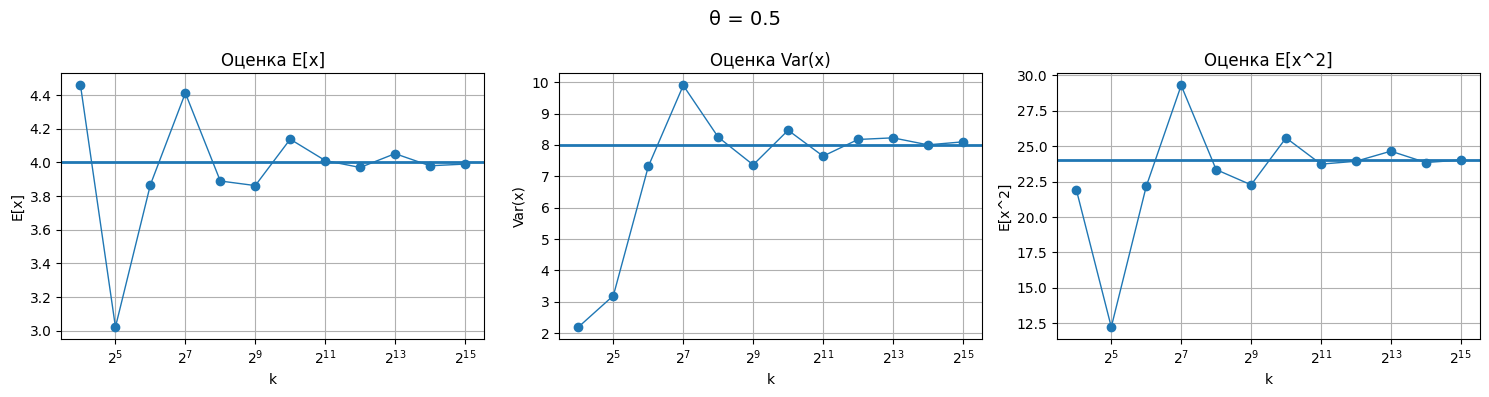

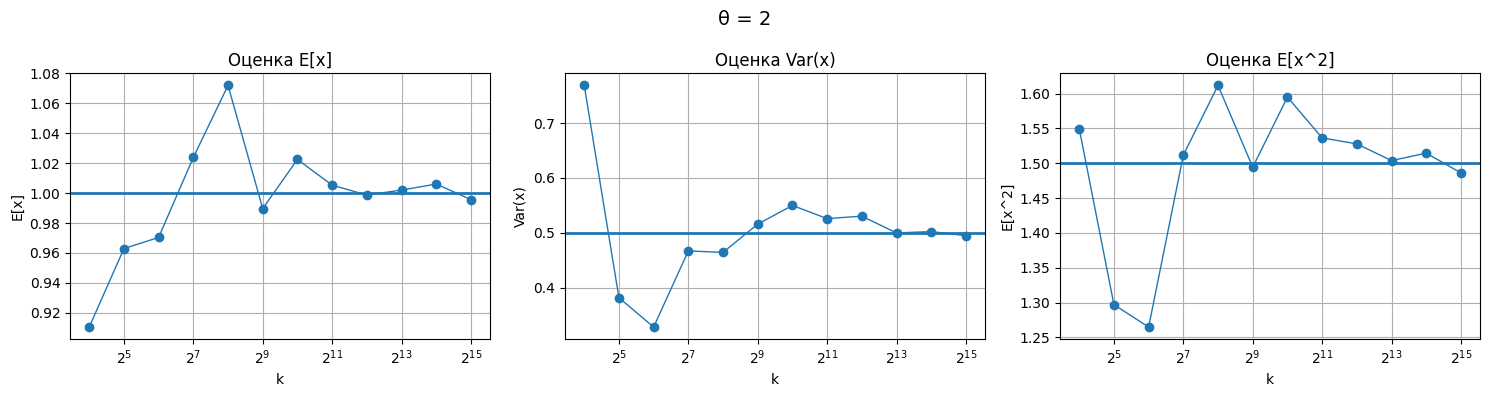

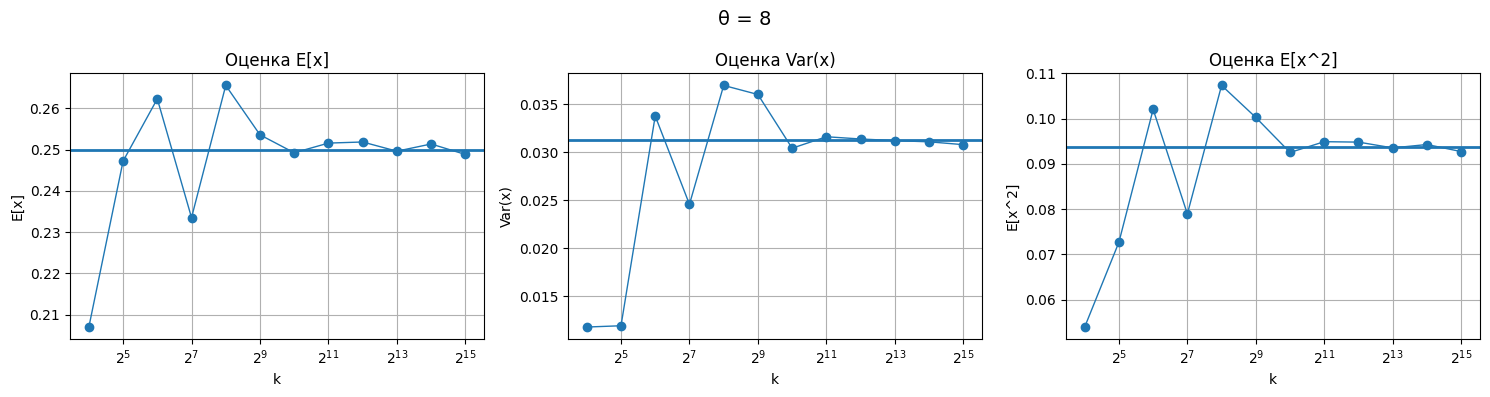

In [6]:
metrics = [
    ("mean", "E",   "E[x]",   "Оценка E[x]"),
    ("var",  "Var", "Var(x)", "Оценка Var(x)"),
    ("ex2",  "E2",  "E[x^2]", "Оценка E[x^2]"),
]

for th in thetas:
    a = analytic_values(th)
    r = results[th]

    fig, axes = plt.subplots(1, 3, figsize=(15, 4), sharex=True)

    for ax, (key, akey, ylabel, title) in zip(axes, metrics):
        ax.plot(r["k"], r[key], marker="o", linewidth=1)
        ax.axhline(a[akey], linewidth=2)
        ax.set_xscale("log", base=2)
        ax.set_xlabel("k")
        ax.set_ylabel(ylabel)
        ax.set_title(title)
        ax.grid(True)

    fig.suptitle(f"θ = {th}", fontsize=14)
    plt.tight_layout()
    plt.show()


### Вывод

При увеличении размера выборки k оценки среднего, дисперсии и E[ξ²] стремятся к аналитическим значениям.
Для больших θ распределение более “сжатое” (среднее меньше), и оценки стабилизируются быстрее.


## Лабораторная работа №2

Случайная величина ξ имеет плотность распределения

f(x) = λ · exp(−λ(x − a)),  x ≥ a  
f(x) = 0,                x < a

Пусть параметры распределения равны λ = 2 и a = 2.

Требуется:

(a) Аналитически вычислить моду, математическое ожидание и медиану.

(b) Построить оценки моды, математического ожидания и медианы
    по двум выборкам:
    - большой выборке (например, 10000 наблюдений),
    - малой выборке (например, 20 наблюдений).

(c) Для каждой выборки построить на одном графике:
    - гистограмму распределения,
    - вертикальные линии оценок моды, математического ожидания и медианы.
    Также построить отдельный график с плотностью распределения и
    аналитическими значениями моды, матожидания и медианы.

(d) Изменить размер выборки и исследовать, сходится ли медиана
    к математическому ожиданию.


### 1.1.2 (a) Аналитические характеристики

Рассматриваемое распределение — экспоненциальное со сдвигом a.

Известны аналитические формулы:

- мода равна a;
- математическое ожидание равно a + 1/λ;
- медиана равна a + (ln 2) / λ.

При λ = 2 и a = 2 получаем конкретные значения,
которые будем использовать для сравнения с выборочными оценками.


In [10]:
import numpy as np
import matplotlib.pyplot as plt

lam = 2.0
a = 2.0

mode_analytic = a
mean_analytic = a + 1.0 / lam
median_analytic = a + np.log(2.0) / lam

mean_analytic, median_analytic, mode_analytic


(2.5, 2.3465735902799727, 2.0)

In [8]:
rng = np.random.default_rng(123)

def sample_shifted_exponential(lam: float, a: float, n: int, rng) -> np.ndarray:
    return a + rng.exponential(scale=1.0/lam, size=n)

sample_big = sample_shifted_exponential(lam, a, 10_000, rng)
sample_small = sample_shifted_exponential(lam, a, 20, rng)


In [9]:
def estimates(sample: np.ndarray) -> dict:
    return {
        "mean": float(np.mean(sample)),
        "median": float(np.median(sample)),
        "mode": float(np.min(sample))  # оценка моды для экспоненциального распределения
    }

est_big = estimates(sample_big)
est_small = estimates(sample_small)

est_big, est_small


({'mean': 2.488259362845467,
  'median': 2.334135138585391,
  'mode': 2.000040097239557},
 {'mean': 2.565019906233674,
  'median': 2.6034335803268105,
  'mode': 2.012195269445597})

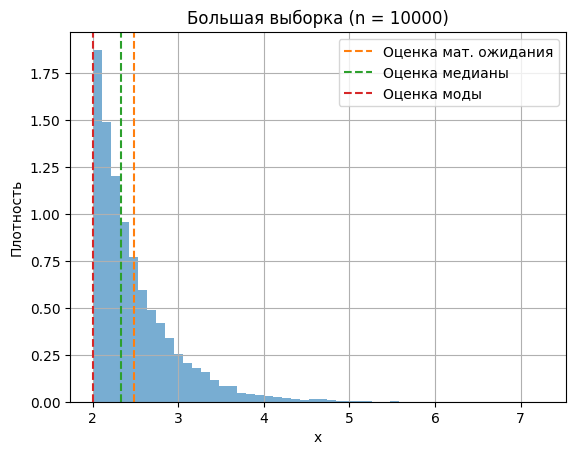

In [12]:
plt.figure()
plt.hist(sample_big, bins=50, density=True, alpha=0.6)

plt.axvline(est_big["mean"],   color="C1", linestyle="--", label="Оценка мат. ожидания")
plt.axvline(est_big["median"], color="C2", linestyle="--", label="Оценка медианы")
plt.axvline(est_big["mode"],   color="C3", linestyle="--", label="Оценка моды")

plt.xlabel("x")
plt.ylabel("Плотность")
plt.title("Большая выборка (n = 10000)")
plt.legend()
plt.grid(True)
plt.show()



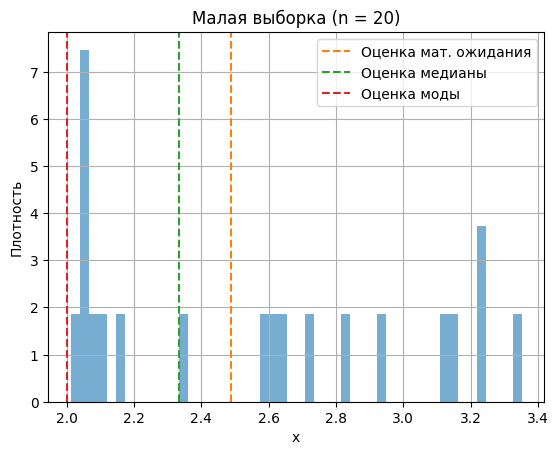

In [15]:
plt.figure()
plt.hist(sample_small, bins=50, density=True, alpha=0.6)

plt.axvline(est_big["mean"],   color="C1", linestyle="--", label="Оценка мат. ожидания")
plt.axvline(est_big["median"], color="C2", linestyle="--", label="Оценка медианы")
plt.axvline(est_big["mode"],   color="C3", linestyle="--", label="Оценка моды")

plt.xlabel("x")
plt.ylabel("Плотность")
plt.title("Малая выборка (n = 20)")
plt.legend()
plt.grid(True)
plt.show()



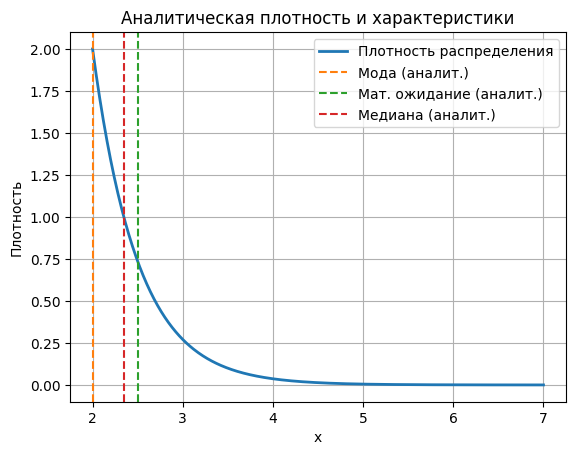

In [17]:
x = np.linspace(a, a + 5, 500)
pdf = lam * np.exp(-lam * (x - a))

plt.figure()
plt.plot(x, pdf, color="C0", linewidth=2, label="Плотность распределения")

plt.axvline(mode_analytic,   color="C1", linestyle="--", label="Мода (аналит.)")
plt.axvline(mean_analytic,   color="C2", linestyle="--", label="Мат. ожидание (аналит.)")
plt.axvline(median_analytic, color="C3", linestyle="--", label="Медиана (аналит.)")

plt.xlabel("x")
plt.ylabel("Плотность")
plt.title("Аналитическая плотность и характеристики")
plt.legend()
plt.grid(True)
plt.show()


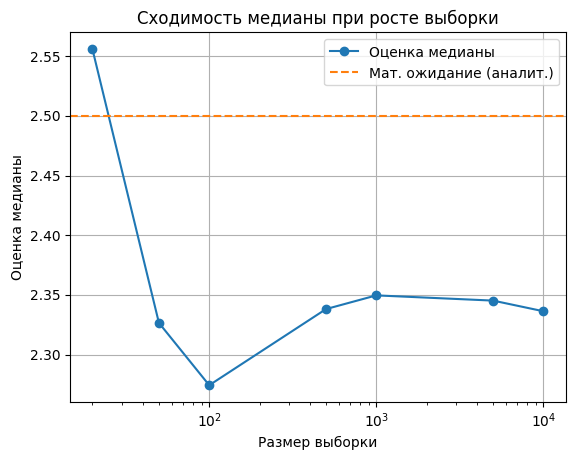

In [18]:
sizes = [20, 50, 100, 500, 1000, 5000, 10000]
medians = []

for n in sizes:
    s = sample_shifted_exponential(lam, a, n, rng)
    medians.append(np.median(s))

plt.figure()
plt.plot(
    sizes, medians,
    marker="o",
    color="C0",
    label="Оценка медианы"
)

plt.axhline(
    mean_analytic,
    color="C1",
    linestyle="--",
    label="Мат. ожидание (аналит.)"
)

plt.xscale("log")
plt.xlabel("Размер выборки")
plt.ylabel("Оценка медианы")
plt.title("Сходимость медианы при росте выборки")
plt.legend()
plt.grid(True)
plt.show()


### Вывод

Для большой выборки оценки моды, математического ожидания и медианы
близки к аналитическим значениям.


## 1.2 Моделирование совместного распределения двух СВ

Совместное распределение двух случайных величин ξ и η задано таблицей:

- ξ принимает значения −1, 0, 1.
- η принимает все значения из множества натуральных чисел 1, 2, 3, …

Вероятности заданы так, что для каждого значения ξ:
- P(η = 1 | ξ) = 1/2
- P(η = 2 | ξ) = 1/4
- P(η = 3 | ξ) = 1/8
- и так далее, то есть P(η = k | ξ) = (1/2)^k.

При этом вероятности ξ равны:
- P(ξ = −1) = 2/5
- P(ξ = 0)  = 1/5
- P(ξ = 1)  = 2/5

Требуется вычислить корреляционную матрицу:
1) аналитически,
2) приближенно на основе моделирования.


### Решение

Сначала найдём маргинальное распределение случайной величины ξ.

Совместное распределение задано так, что для каждого фиксированного значения ξ
вероятности по η образуют геометрический ряд с множителем 1/2.
Поэтому при суммировании по всем значениям η используем сумму бесконечной геометрической прогрессии.

Для ξ = −1 и ξ = 1 получаем:
$$
P(\xi = -1) = P(\xi = 1)
= \frac{2}{5}\left(\frac{1}{2} + \frac{1}{2^2} + \frac{1}{2^3} + \dots \right)
= \frac{2}{5}.
$$

Для ξ = 0:
$$
P(\xi = 0)
= \frac{1}{5}\left(\frac{1}{2} + \frac{1}{2^2} + \frac{1}{2^3} + \dots \right)
= \frac{1}{5}.
$$

Таким образом, маргинальное распределение ξ имеет вид:

| ξ | −1 | 0 | 1 |
|---|----|---|---|
| P | 2/5 | 1/5 | 2/5 |

Теперь найдём маргинальное распределение η.
Для любого натурального k вероятность того, что η равно k, равна сумме
совместных вероятностей по всем возможным значениям ξ:
$$
P(\eta = k)
= \sum_{a\in\{-1,0,1\}} P(\xi = a, \eta = k)
= \frac{2}{5}\cdot\frac{1}{2^k}
+ \frac{1}{5}\cdot\frac{1}{2^k}
+ \frac{2}{5}\cdot\frac{1}{2^k}
= \frac{1}{2^k}.
$$

Следовательно, случайная величина η имеет геометрическое распределение
с параметром 1/2.

Проверим независимость случайных величин ξ и η.
Для любых допустимых значений a из множества {−1, 0, 1}
и k из множества натуральных чисел выполняется:
$$
P(\xi = a, \eta = k)
= P(\xi = a)\,P(\eta = k).
$$

Так как это равенство верно для всех возможных значений,
случайные величины ξ и η являются независимыми.

Из независимости следует, что ковариация равна нулю:
$$
\operatorname{cov}(\xi,\eta) = 0,
\qquad
\rho(\xi,\eta) = 0.
$$

Корреляционная матрица имеет вид:
$$
\begin{pmatrix}
1 & 0 \\
0 & 1
\end{pmatrix}.
$$

Таким образом, случайные величины ξ и η независимы и некоррелированы.


In [22]:
import numpy as np
from scipy import stats

rng = np.random.default_rng(2024)

xi_values = np.array([-1, 0, 1])
xi_probs = np.array([0.4, 0.2, 0.4])
xi_sample = rng.choice(xi_values, size=100_000, p=xi_probs)

eta_sample = rng.geometric(p=0.5, size=100_000)

corr_matrix = np.corrcoef(xi_sample, eta_sample)
corr_matrix


array([[1.        , 0.00207586],
       [0.00207586, 1.        ]])